## Name : Sulaiman Alfawzan

# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [2]:
import pandas as pd
import sklearn
from pathlib import Path

DATA_PATH = Path('./Data/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv')
print(DATA_PATH.resolve())
print(DATA_PATH.exists())

C:\Users\xxslo\OneDrive\Desktop\AAI-bootcamp\student\C3\M1\Data\Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv
True


### Step 1. Load the data

In [3]:
# pd.read_csv("../../../datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv").head()

In [4]:
df = pd.read_csv("./Data/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [5]:
x=df['Hours_Studied'].values
y=df['Marks'].values

### Step 2.b print the type of each

In [6]:
type(x), type(y)

(numpy.ndarray, numpy.ndarray)

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [7]:
# Both of y and x are numerical variables.
# Since the target y is numerical  this is a regression.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (100,)
y shape: (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
df.agg(['min', 'max','median','mean', 'std'])

,Hours_Studied,Marks
min,1.050000,20.190000
max,9.870000,73.260000
median,5.565000,47.485000
mean,5.376300,46.360200
std,2.593013,14.284805


### Step 5. Plot the feature vs the target

Text(0.5, 1.0, 'Hours Studied vs Marks')

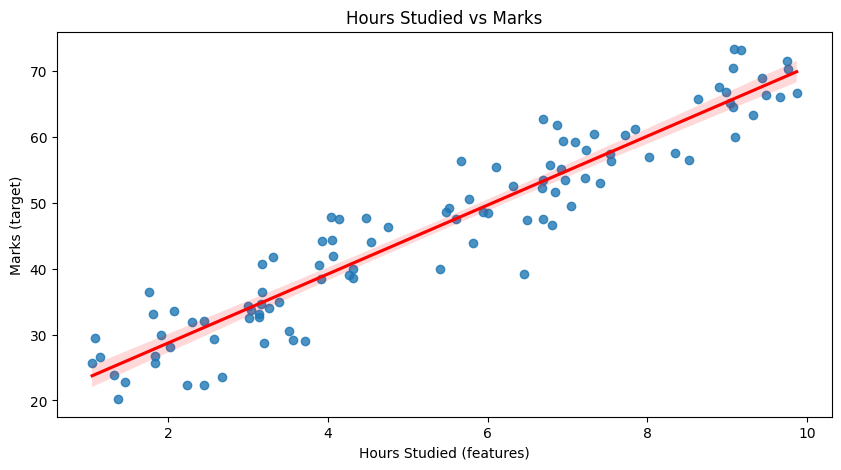

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.regplot(x='Hours_Studied', y='Marks', data=df, line_kws={'color':'red'})
plt.xlabel('Hours Studied (features)')
plt.ylabel('Marks (target)')
plt.title('Hours Studied vs Marks')

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [11]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(df['Hours_Studied'], df['Marks'])
print("its incerasing by ",r_value**2)

its incerasing by  0.9005509767526406


### Step 7. Initialize a `LinearRegression` model

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [13]:
from sklearn.model_selection import train_test_split

X = x.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

### Step 9.a Train the model on the training set

In [14]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [15]:
model.coef_[0].round(2), model.intercept_.round(2)
print(f"This means the model learned:\nf(x) = {model.coef_[0].round(2)} * x + {model.intercept_.round(2)}")

This means the model learned:
f(x) = 5.16 * x + 18.54


### Step 9.c how much marks do we get per 1 hour of study?

In [16]:
model.predict([[1]])


array([23.70301693])

### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [17]:
increase_10min = model.coef_[0] * (1/6)
print(f"{increase_10min:.2f}")

0.86


### Step 9.e if one doesn't study at all, how much marks do they get?

In [18]:
model.predict([[0]])

array([18.53857851])

### Step 10. Evaluate the model on the test set

In [19]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "hours_studied": X_test.flatten(),
    "true": y_test,
    "predicted": y_pred.round(2)
}).reset_index(drop=True)
comparison.sample(5)

,hours_studied,true,predicted
0,3.02,32.50,34.14
8,9.66,65.99,68.43
6,2.30,31.86,30.42
16,1.91,30.00,28.40
10,1.46,22.78,26.08


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [20]:
comparison.sample(3)
# The values are close, but they do not match exactly. 

,hours_studied,true,predicted
18,5.48,48.59,46.84
19,6.69,62.72,53.09
14,6.92,55.08,54.28


### Step 12. Plot the data and the regression line

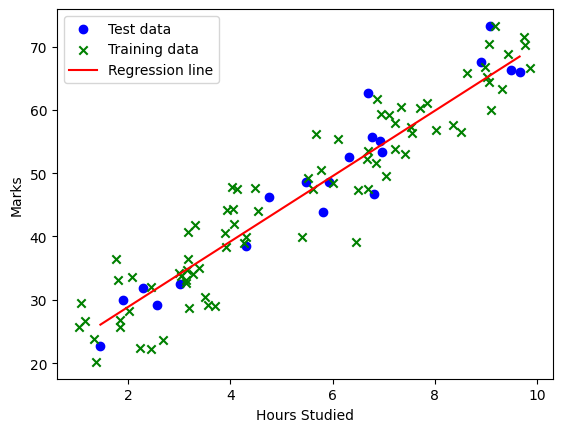

In [22]:
import numpy as np

plt.scatter(X_test, y_test, label='Test data', marker='o', color='blue')
plt.scatter(X_train, y_train, label='Training data' ,marker='x', color='green')

x_line = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='red', label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.legend()
plt.show()